# Bag of Words, TF-IDF y n-gramas

**Duración estimada:** 45 minutos

---

## Objetivo

Ya viste cómo construir una tabla Bag of Words en `000_intuicion_bag_of_words.ipynb`. Ahora vas a comparar tres formas de representar un corpus:
- **Bag of Words**, que cuenta ocurrencias;
- **TF-IDF**, que pondera la importancia real de cada palabra;
- **N-gramas**, que recuperan términos compuestos como "Buenos Aires".

## Resultados de aprendizaje
Al final deberías poder:
- diferenciar frecuencia de importancia relativa;
- explicar por qué TF-IDF destaca términos específicos y no solo frecuentes;
- detectar cuándo un bigrama agrega información que el unigrama pierde;
- elegir una representación inicial según tu pregunta analítica.

In [7]:
# Importamos las herramientas que necesitamos
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt

---

## 1. Nuestro corpus

Vamos a usar los mismos textos del cuaderno anterior más uno nuevo. Así podés rastrear cómo cambian los resultados al pasar de BoW a TF-IDF sobre **los mismos datos**.

In [8]:
# Los mismos textos del cuaderno anterior + uno nuevo
textos = [
    "El perro ladra fuerte",    # del cuaderno anterior
    "El gato come pescado",     # del cuaderno anterior
    "El perro come carne",      # del cuaderno anterior
    "El gato come mucho"        # nuevo
]

etiquetas = ["Texto 1", "Texto 2", "Texto 3", "Texto 4"]

print("Nuestro corpus:")
for etiqueta, texto in zip(etiquetas, textos):
    print(f"  {etiqueta}: {texto}")

Nuestro corpus:
  Texto 1: El perro ladra fuerte
  Texto 2: El gato come pescado
  Texto 3: El perro come carne
  Texto 4: El gato come mucho


---

## 2. Bag of Words: la línea de base

Bag of Words responde una pregunta sencilla: **¿cuántas veces aparece cada palabra en cada documento?**

Ya lo hicimos en el cuaderno anterior; acá lo repetimos rápidamente para tener los datos listos.

In [9]:
# Paso 1: creamos el contador automático
contador_bow = CountVectorizer()

# Paso 2: le damos los textos para que cuente las palabras
matriz_bow = contador_bow.fit_transform(textos)

# Paso 3: mostramos la tabla
vocabulario = contador_bow.get_feature_names_out()
tabla_bow = pd.DataFrame(
    matriz_bow.toarray(),
    columns=vocabulario,
    index=etiquetas
)

print("Tabla Bag of Words:")
print(tabla_bow)
print(f"\nDimensiones: {tabla_bow.shape[0]} documentos × {tabla_bow.shape[1]} palabras")

Tabla Bag of Words:
         carne  come  el  fuerte  gato  ladra  mucho  perro  pescado
Texto 1      0     0   1       1     0      1      0      1        0
Texto 2      0     1   1       0     1      0      0      0        1
Texto 3      1     1   1       0     0      0      0      1        0
Texto 4      0     1   1       0     1      0      1      0        0

Dimensiones: 4 documentos × 9 palabras


---

## 3. TF-IDF: no todo lo frecuente es igual de informativo

### El problema de BoW
Un problema con Bag of Words es que le da el mismo peso a todas las palabras. Mirá la tabla de arriba: **"el"** aparece en **todos** los documentos. ¿Realmente nos dice algo útil sobre cada texto? No mucho.

### La solución: TF-IDF
**TF-IDF** (Term Frequency – Inverse Document Frequency) es una mejora que asigna un **peso** a cada palabra según su importancia real.

Se calcula con dos componentes:
- **TF (Term Frequency):** cuántas veces aparece la palabra en un documento. Es similar a BoW.
- **IDF (Inverse Document Frequency):** cuán "rara" o "única" es esa palabra en todo el corpus. Las palabras que aparecen en muchos documentos (como "el") tienen IDF bajo.

El peso final es **TF × IDF**: una palabra tendrá peso alto si aparece mucho en *ese* documento, pero en *pocos* documentos del resto del corpus.

In [10]:
# Paso 1: creamos el vectorizador TF-IDF
# Funciona igual que CountVectorizer, pero calcula pesos en vez de conteos
vectorizador_tfidf = TfidfVectorizer()

# Paso 2: le damos los mismos textos
matriz_tfidf = vectorizador_tfidf.fit_transform(textos)

# Paso 3: mostramos la tabla con pesos TF-IDF
vocabulario_tfidf = vectorizador_tfidf.get_feature_names_out()
tabla_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    columns=vocabulario_tfidf,
    index=etiquetas
)

print("Tabla TF-IDF:")
print(tabla_tfidf.round(3))  # Redondeamos para que sea más legible

Tabla TF-IDF:
         carne   come     el  fuerte  gato  ladra  mucho  perro  pescado
Texto 1  0.000  0.000  0.307   0.588  0.00  0.588  0.000  0.463    0.000
Texto 2  0.000  0.421  0.344   0.000  0.52  0.000  0.000  0.000    0.659
Texto 3  0.659  0.421  0.344   0.000  0.00  0.000  0.000  0.520    0.000
Texto 4  0.000  0.421  0.344   0.000  0.52  0.000  0.659  0.000    0.000


---

## 4. Comparación: BoW vs TF-IDF

Ahora pongamos ambas representaciones una al lado de la otra para el **Texto 3** ("El perro come carne") y veamos la diferencia.

In [11]:
# Comparemos las dos representaciones para un documento
doc_a_comparar = "Texto 3"

print(f"Comparación para '{doc_a_comparar}' ({textos[2]})")
print("\n--- Bag of Words (conteos) ---")
print(tabla_bow.loc[doc_a_comparar])

print("\n--- TF-IDF (pesos) ---")
print(tabla_tfidf.loc[doc_a_comparar].round(3))

Comparación para 'Texto 3' (El perro come carne)

--- Bag of Words (conteos) ---
carne      1
come       1
el         1
fuerte     0
gato       0
ladra      0
mucho      0
perro      1
pescado    0
Name: Texto 3, dtype: int64

--- TF-IDF (pesos) ---
carne      0.659
come       0.421
el         0.344
fuerte     0.000
gato       0.000
ladra      0.000
mucho      0.000
perro      0.520
pescado    0.000
Name: Texto 3, dtype: float64


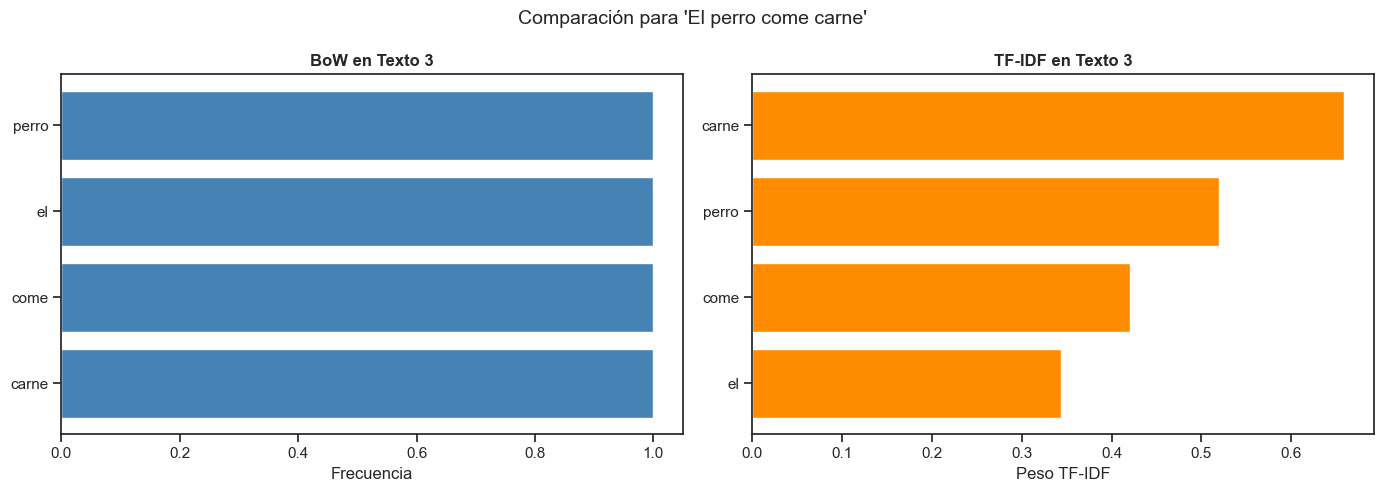

In [12]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Bag of Words
valores_bow = tabla_bow.loc[doc_a_comparar]
valores_bow_positivos = valores_bow[valores_bow > 0].sort_values(ascending=True)
axes[0].barh(valores_bow_positivos.index, valores_bow_positivos.values, color="steelblue")
axes[0].set_title(f"BoW en {doc_a_comparar}", fontweight="bold")
axes[0].set_xlabel("Frecuencia")

# Gráfico 2: TF-IDF
valores_tfidf = tabla_tfidf.loc[doc_a_comparar]
valores_tfidf_positivos = valores_tfidf[valores_tfidf > 0].sort_values(ascending=True)
axes[1].barh(valores_tfidf_positivos.index, valores_tfidf_positivos.values, color="darkorange")
axes[1].set_title(f"TF-IDF en {doc_a_comparar}", fontweight="bold")
axes[1].set_xlabel("Peso TF-IDF")

plt.suptitle(f"Comparación para '{textos[2]}'", fontsize=14)
plt.tight_layout()
plt.show()

### Análisis de los resultados

Observá las diferencias:
- En **BoW**, todas las palabras presentes en el documento ("carne", "come", "el", "perro") tienen un valor de **1**. Todas pesan igual.
- En **TF-IDF**, las palabras **"carne"** y **"perro"** tienen peso más alto que **"el"** y **"come"**.

¿Por qué? Porque **"el"** aparece en todos los documentos (no ayuda a distinguir nada) y **"come"** aparece en tres de los cuatro. En cambio, **"carne"** aparece solamente en este documento, así que TF-IDF le asigna el peso más alto: es la palabra que mejor lo define.

**Conclusión:** TF-IDF identifica automáticamente cuáles son las palabras más importantes para cada documento.

---

## 5. N-gramas: cuando una palabra sola no alcanza

### El problema
Hasta ahora tratamos cada palabra de forma individual (esto se llama usar **unigramas**). Pero eso tiene una limitación: perdemos el significado de términos compuestos como **"Buenos Aires"** o **"inteligencia artificial"**.

### La solución: n-gramas
Los **n-gramas** son secuencias de N palabras consecutivas:
- **Unigramas** (N=1): palabras sueltas → "Buenos", "Aires"
- **Bigramas** (N=2): pares de palabras → "Buenos Aires"
- **Trigramas** (N=3): tríos de palabras → "Mar del Plata"

Al incluir n-gramas en nuestro vocabulario, podemos capturar estos términos compuestos como si fueran un solo token.

In [13]:
# Un mini corpus con términos compuestos argentinos
textos_ciudades = [
    "Buenos Aires es la capital de Argentina",
    "Visité Mar del Plata y Buenos Aires el verano pasado"
]

# -------------------------------------------------------
# Problema: con unigramas, se pierden los nombres propios
# -------------------------------------------------------
print("1. Analizando con palabras sueltas (unigramas)")

vectorizador_uni = CountVectorizer()
vectorizador_uni.fit_transform(textos_ciudades)

vocabulario_uni = vectorizador_uni.get_feature_names_out()

# Buscamos las palabras que nos interesan
palabras_a_buscar = ["buenos", "aires", "mar", "del", "plata"]
encontradas = []
for palabra in vocabulario_uni:
    if palabra in palabras_a_buscar:
        encontradas.append(palabra)

print(f"\nVocabulario (extracto): {encontradas}")
print("→ 'Buenos' y 'Aires' son tokens separados. Se pierde el concepto de la ciudad.")

1. Analizando con palabras sueltas (unigramas)

Vocabulario (extracto): ['aires', 'buenos', 'del', 'mar', 'plata']
→ 'Buenos' y 'Aires' son tokens separados. Se pierde el concepto de la ciudad.


In [14]:
# -------------------------------------------------------
# Solución: con n-gramas, se recuperan los nombres propios
# -------------------------------------------------------
print("2. Analizando con unigramas, bigramas y trigramas")

# ngram_range=(1, 3) incluye tokens de 1, 2 y 3 palabras
vectorizador_ngram = CountVectorizer(ngram_range=(1, 3))
matriz_ngram = vectorizador_ngram.fit_transform(textos_ciudades)

vocabulario_ngram = vectorizador_ngram.get_feature_names_out()

# Buscamos los términos que nos interesan
terminos_interes = [
    "buenos", "aires", "buenos aires",
    "mar", "del", "plata", "mar del", "del plata", "mar del plata"
]

encontrados_ngram = []
for termino in vocabulario_ngram:
    if termino in terminos_interes:
        encontrados_ngram.append(termino)

print(f"\nVocabulario (extracto): {encontrados_ngram}")
print("→ Ahora 'buenos aires' y 'mar del plata' son tokens únicos.")

# Mostramos la matriz para el segundo documento
tabla_ngram = pd.DataFrame(
    matriz_ngram.toarray(),
    columns=vocabulario_ngram,
    index=["Doc 1", "Doc 2"]
)

print("\nConteo de n-gramas para Doc 2 (extracto):")
print(tabla_ngram.loc["Doc 2", terminos_interes])

2. Analizando con unigramas, bigramas y trigramas

Vocabulario (extracto): ['aires', 'buenos', 'buenos aires', 'del', 'del plata', 'mar', 'mar del', 'mar del plata', 'plata']
→ Ahora 'buenos aires' y 'mar del plata' son tokens únicos.

Conteo de n-gramas para Doc 2 (extracto):
buenos           1
aires            1
buenos aires     1
mar              1
del              1
plata            1
mar del          1
del plata        1
mar del plata    1
Name: Doc 2, dtype: int64


---

## 6. Pausa de lectura crítica

- **Bag of Words** sirve para ver recurrencias y volumen.
- **TF-IDF** sirve para detectar qué términos son distintivos dentro de un conjunto.
- **Los n-gramas** sirven para recuperar términos compuestos que el unigrama rompe.

Ninguna de estas representaciones produce interpretación por sí sola. Te ayudan a formular mejores preguntas para volver al texto.

## Actividad breve
1. Elegí un documento del corpus y compará sus palabras en BoW vs TF-IDF. ¿Cuál tiene el peso más alto en TF-IDF? ¿Por qué?
2. Buscá un bigrama del ejemplo de n-gramas que diga más que las palabras sueltas por separado.
3. Explicá qué clase de pregunta analítica podrías formular a partir de esa diferencia.

## Cierre
En el próximo cuaderno vas a aplicar este recorrido completo sobre un mini corpus real adquirido con Trafilatura.

---

## Glosario

- **Corpus:** una colección de documentos de texto utilizados para análisis.
- **Vectorización:** el proceso de convertir texto en vectores numéricos.
- **Token:** una unidad de texto, generalmente una palabra.
- **Vocabulario:** el conjunto de todos los tokens únicos presentes en un corpus.
- **Bag of Words (BoW):** un modelo que describe un documento a través del conteo de sus palabras, ignorando el orden.
- **TF-IDF (Term Frequency – Inverse Document Frequency):** una métrica que refleja la importancia de una palabra en un documento dentro de un corpus.
- **N-grama:** una secuencia de N palabras consecutivas. Unigrama (N=1), Bigrama (N=2), Trigrama (N=3).
- **Matriz esparsa:** una matriz donde la mayoría de los valores son cero. Es la forma típica de las representaciones BoW y TF-IDF.